# Week 4: Regression Practice with "housing2" Dataset

## Overview
This practice includes the following steps:

1. **Data Loading and Preparation**
2. **Exploratory Data Analysis (EDA)**
3. **Regression Models**
   - 3.1 Linear Regression
   - 3.2 Ridge Regression
   - 3.3 Lasso Regression

# 1. Data Loading and Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# read the housing dataset
path = '/content/drive/MyDrive/UIUC/IE 498 - Machine Learning in Finance/week4/housing2.csv'
data = pd.read_csv(path, na_values=['NA', 'Nan', 'N/A', 'na', 'n/a', 'null', 'NULL', 'None', 'none', ''])

print(f"{data.columns}")
data.head()

Index(['ATT1', 'ATT2', 'ATT3', 'ATT4', 'ATT5', 'ATT6', 'ATT7', 'ATT8', 'ATT9',
       'ATT10', 'ATT11', 'ATT12', 'ATT13', 'CRIM', 'ZN', 'INDUS', 'CHAS',
       'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT',
       'MEDV'],
      dtype='object')


,ATT1,ATT2,ATT3,ATT4,ATT5,ATT6,ATT7,ATT8,ATT9,ATT10,...,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.038327,0.592379,0.655174,0.119839,0.652477,0.984323,0.206738,0.374650,0.463350,0.333610,...,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.225022,0.983103,0.803619,0.836315,0.163104,0.637497,0.008760,0.631190,0.207978,0.880357,...,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.423233,0.375808,0.271293,0.729824,0.886744,0.043703,0.457700,0.862450,0.901924,0.062488,...,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.743370,0.929103,0.589894,0.644012,0.110490,0.774604,0.306483,0.880599,0.630401,0.928894,...,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.378623,0.786609,0.712752,0.110274,0.762133,0.030069,0.316631,0.667073,0.426443,0.400557,...,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


Dataset description:

* The housing2.csv dataset is an extended version of the original Boston Housing dataset, with 13 additional variables (ATT1~ATT13). It contains housing-related features used to predict median house prices (MEDV).

* The Boston Housing dataset contains information about houses in the suburbs of Boston collected by D. Harrison and D.L. Rubinfeld in 1978. The Housing dataset
has been made freely available and is included in the code bundle of the book.

* There are 13 independent variables corresponding to your X feature set (CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRAIO, B and LSTAT.)

* These features/measurements are believed to be determinants of median housing value for 506 neighborhoods in the Boston metropolitan area.

* CHAS is a binary variable (0,1) all the rest are integer or floating point decimal.

* MEDV (Median Value) is your target value.

* There should be NO missing values.



# 2. Exploratory Data Analysis

### Basic Information

In [3]:
# Basic information

# 1. Number of rows and columns
print("1. Shape of data:")
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

# 2. Number of categorical variables and number of unique values for each
categorical_cols = data.select_dtypes(include=['object', 'category', 'string']).columns
categorical_summary = pd.DataFrame({'number of unique values': data[categorical_cols].nunique()})
print("\n2. Categorical variables:")
display(categorical_summary)

# 3. Missing values
print("\n3. Missing values:")
missing_summary = pd.DataFrame({'Missing Values': data.isnull().sum(), 'Missing Percentage': data.isnull().mean()*100})
display(missing_summary[missing_summary['Missing Values'] > 0])  # print if nan > 0

# 4. Summary statistics for attributes and labels (numerical variables)
numerical_cols = data.select_dtypes(include='number').columns
print("\n4. Summary statistics for numerical attributes:")
display(data[numerical_cols].describe())

1. Shape of data:
Number of rows: 506
Number of columns: 27

2. Categorical variables:


,number of unique values



3. Missing values:


,Missing Values,Missing Percentage



4. Summary statistics for numerical attributes:


,ATT1,ATT2,ATT3,ATT4,ATT5,ATT6,ATT7,ATT8,ATT9,ATT10,...,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,...,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,0.518457,0.500422,0.507451,0.498543,0.525487,0.508831,0.501997,0.509998,0.480159,0.501922,...,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,0.283847,0.298752,0.289607,0.294229,0.283387,0.282400,0.287986,0.290160,0.301086,0.294051,...,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.000727,0.000321,0.000013,0.001541,0.003970,0.000679,0.003653,0.000525,0.001093,0.000263,...,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.272918,0.235879,0.244897,0.229861,0.283208,0.276366,0.271701,0.257320,0.208171,0.248119,...,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.521326,0.485701,0.526014,0.506543,0.514982,0.509443,0.499804,0.508326,0.465558,0.487128,...,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,0.770235,0.774921,0.750546,0.757517,0.772218,0.730899,0.756420,0.768465,0.739580,0.771559,...,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,0.995798,0.999265,0.998746,0.995561,0.998635,0.998194,0.999140,0.997083,0.996714,0.999321,...,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Train-Test Split

In [4]:
# Set target variable
target = 'MEDV'

X = data.drop(columns=[target])
y = data[target]

# train-test split (8:2)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (404, 26)
Test set: (102, 26)


### Visualizations

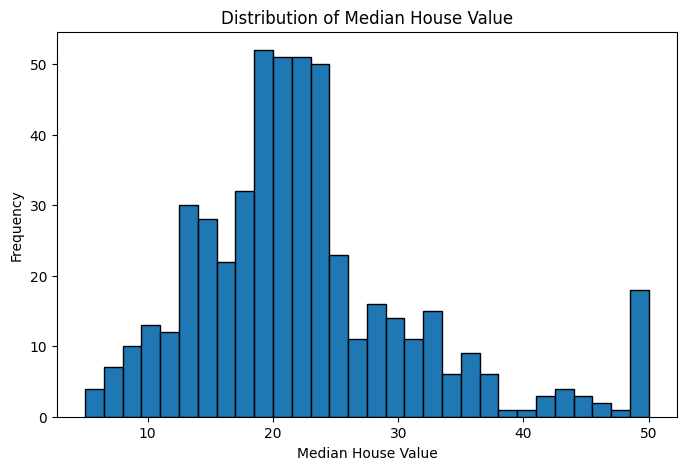

In [5]:
# Distribution of the target variable
plt.figure(figsize=(8, 5))
plt.hist(y, bins=30, edgecolor='black')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.title('Distribution of Median House Value')
# save graph path
graphics_path = '/content/drive/MyDrive/UIUC/IE 498 - Machine Learning in Finance/week4/hw4_graphics/'
plt.savefig(graphics_path + 'Distribution_of_Median_House_Value.png', dpi=300, bbox_inches='tight')
plt.show()

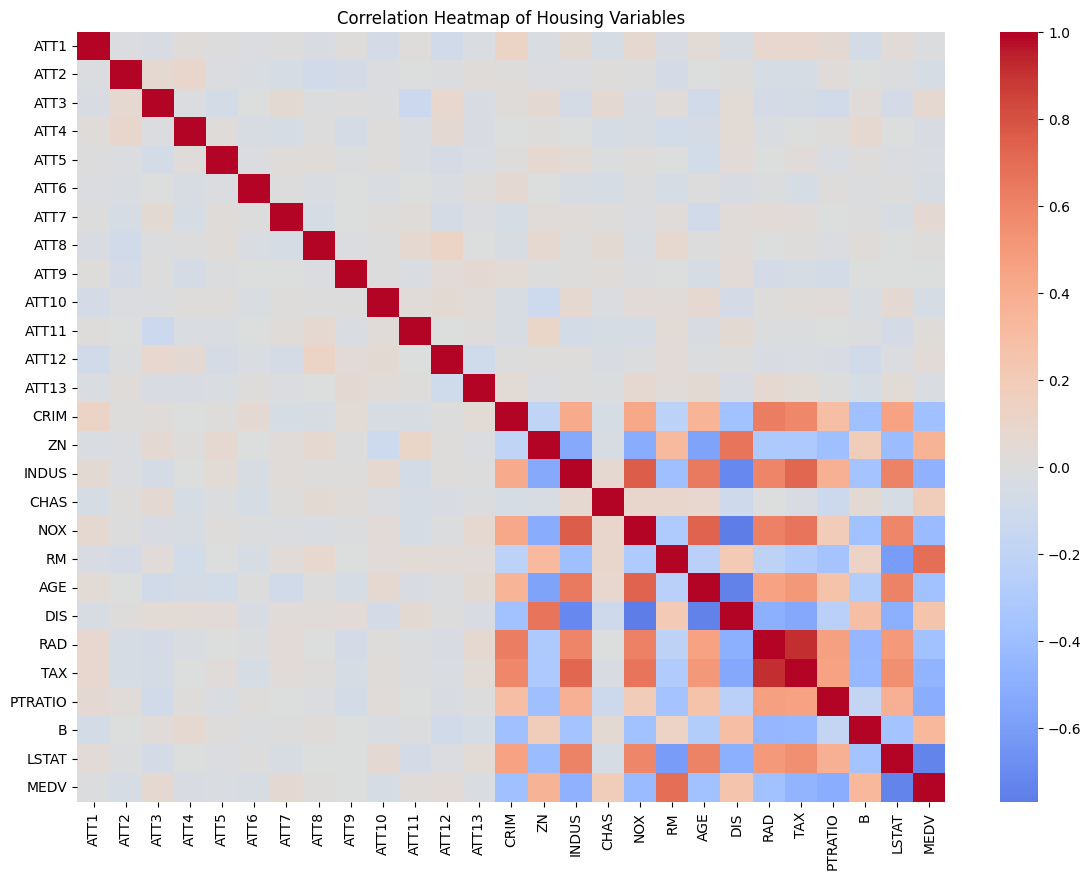

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Housing Variables')
plt.savefig(graphics_path + 'Correlation_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

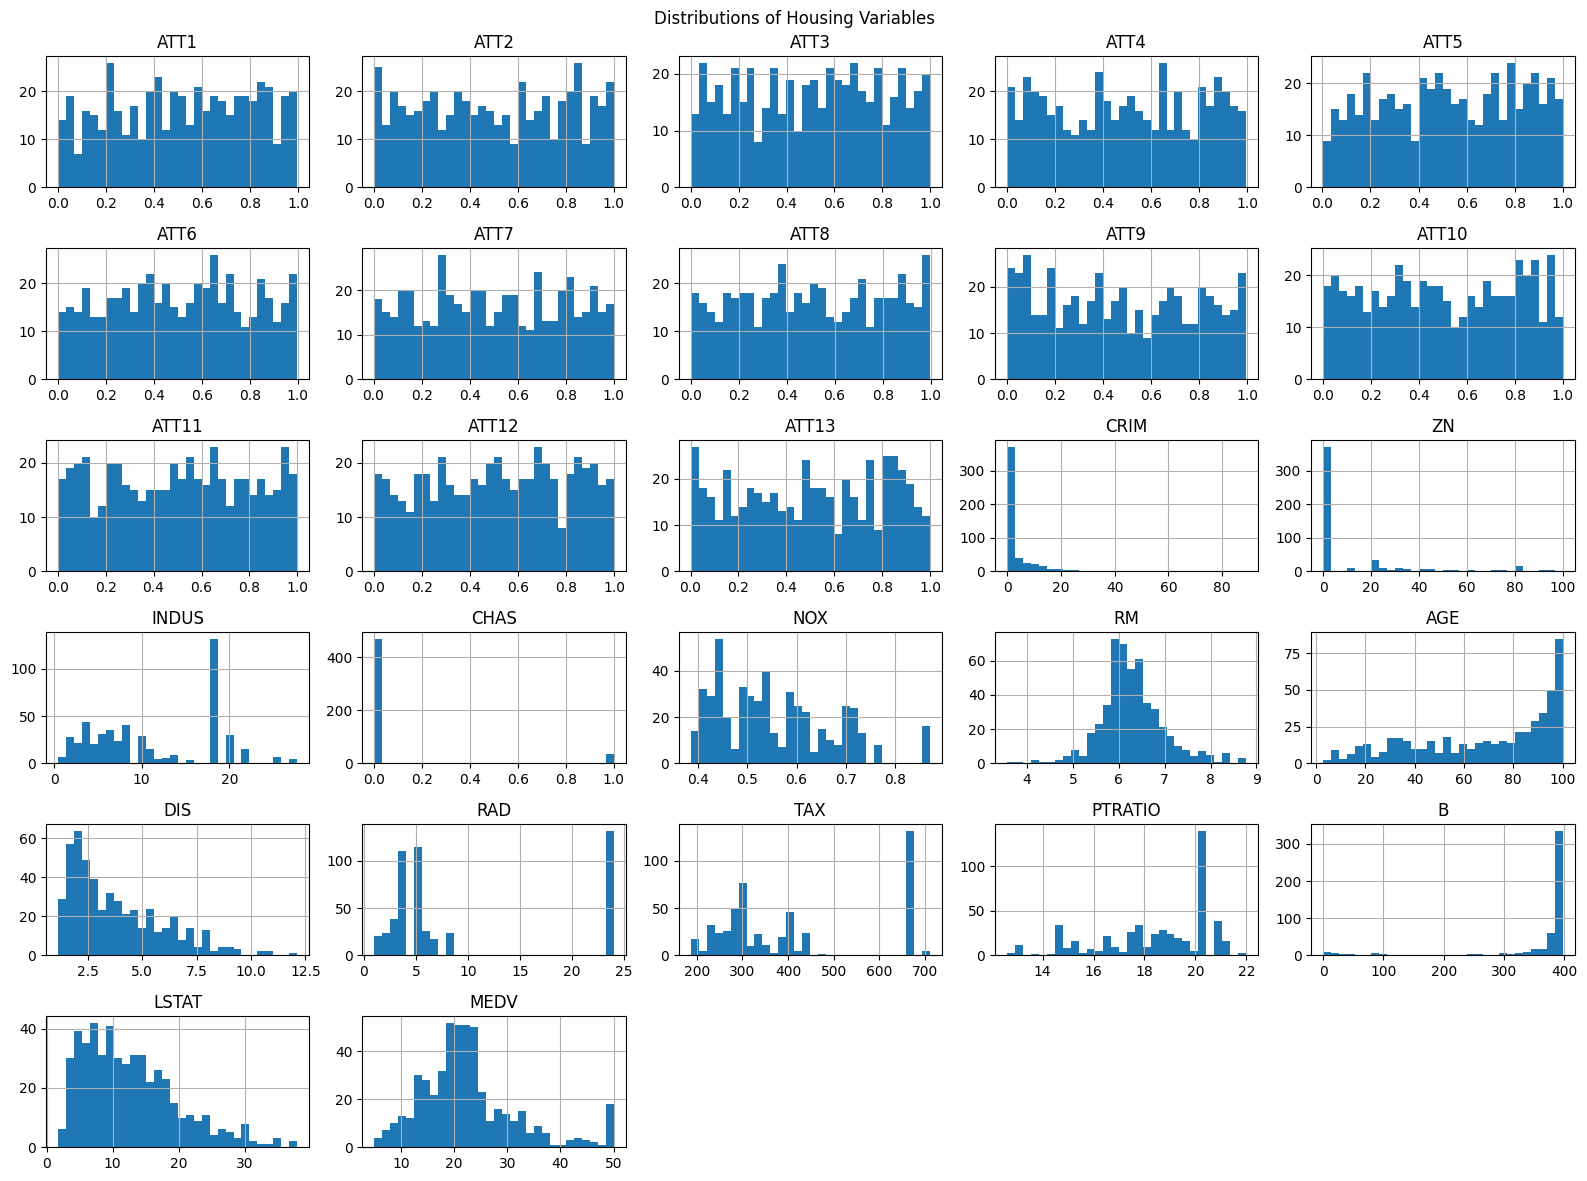

In [ ]:
# Distributions of all housing variables
data.hist(figsize=(16, 12), bins=30)

plt.suptitle('Distributions of Housing Variables')
plt.tight_layout()
plt.savefig(graphics_path + 'Distributions_of_Housing_Variables.png', dpi=300, bbox_inches='tight')
plt.show()

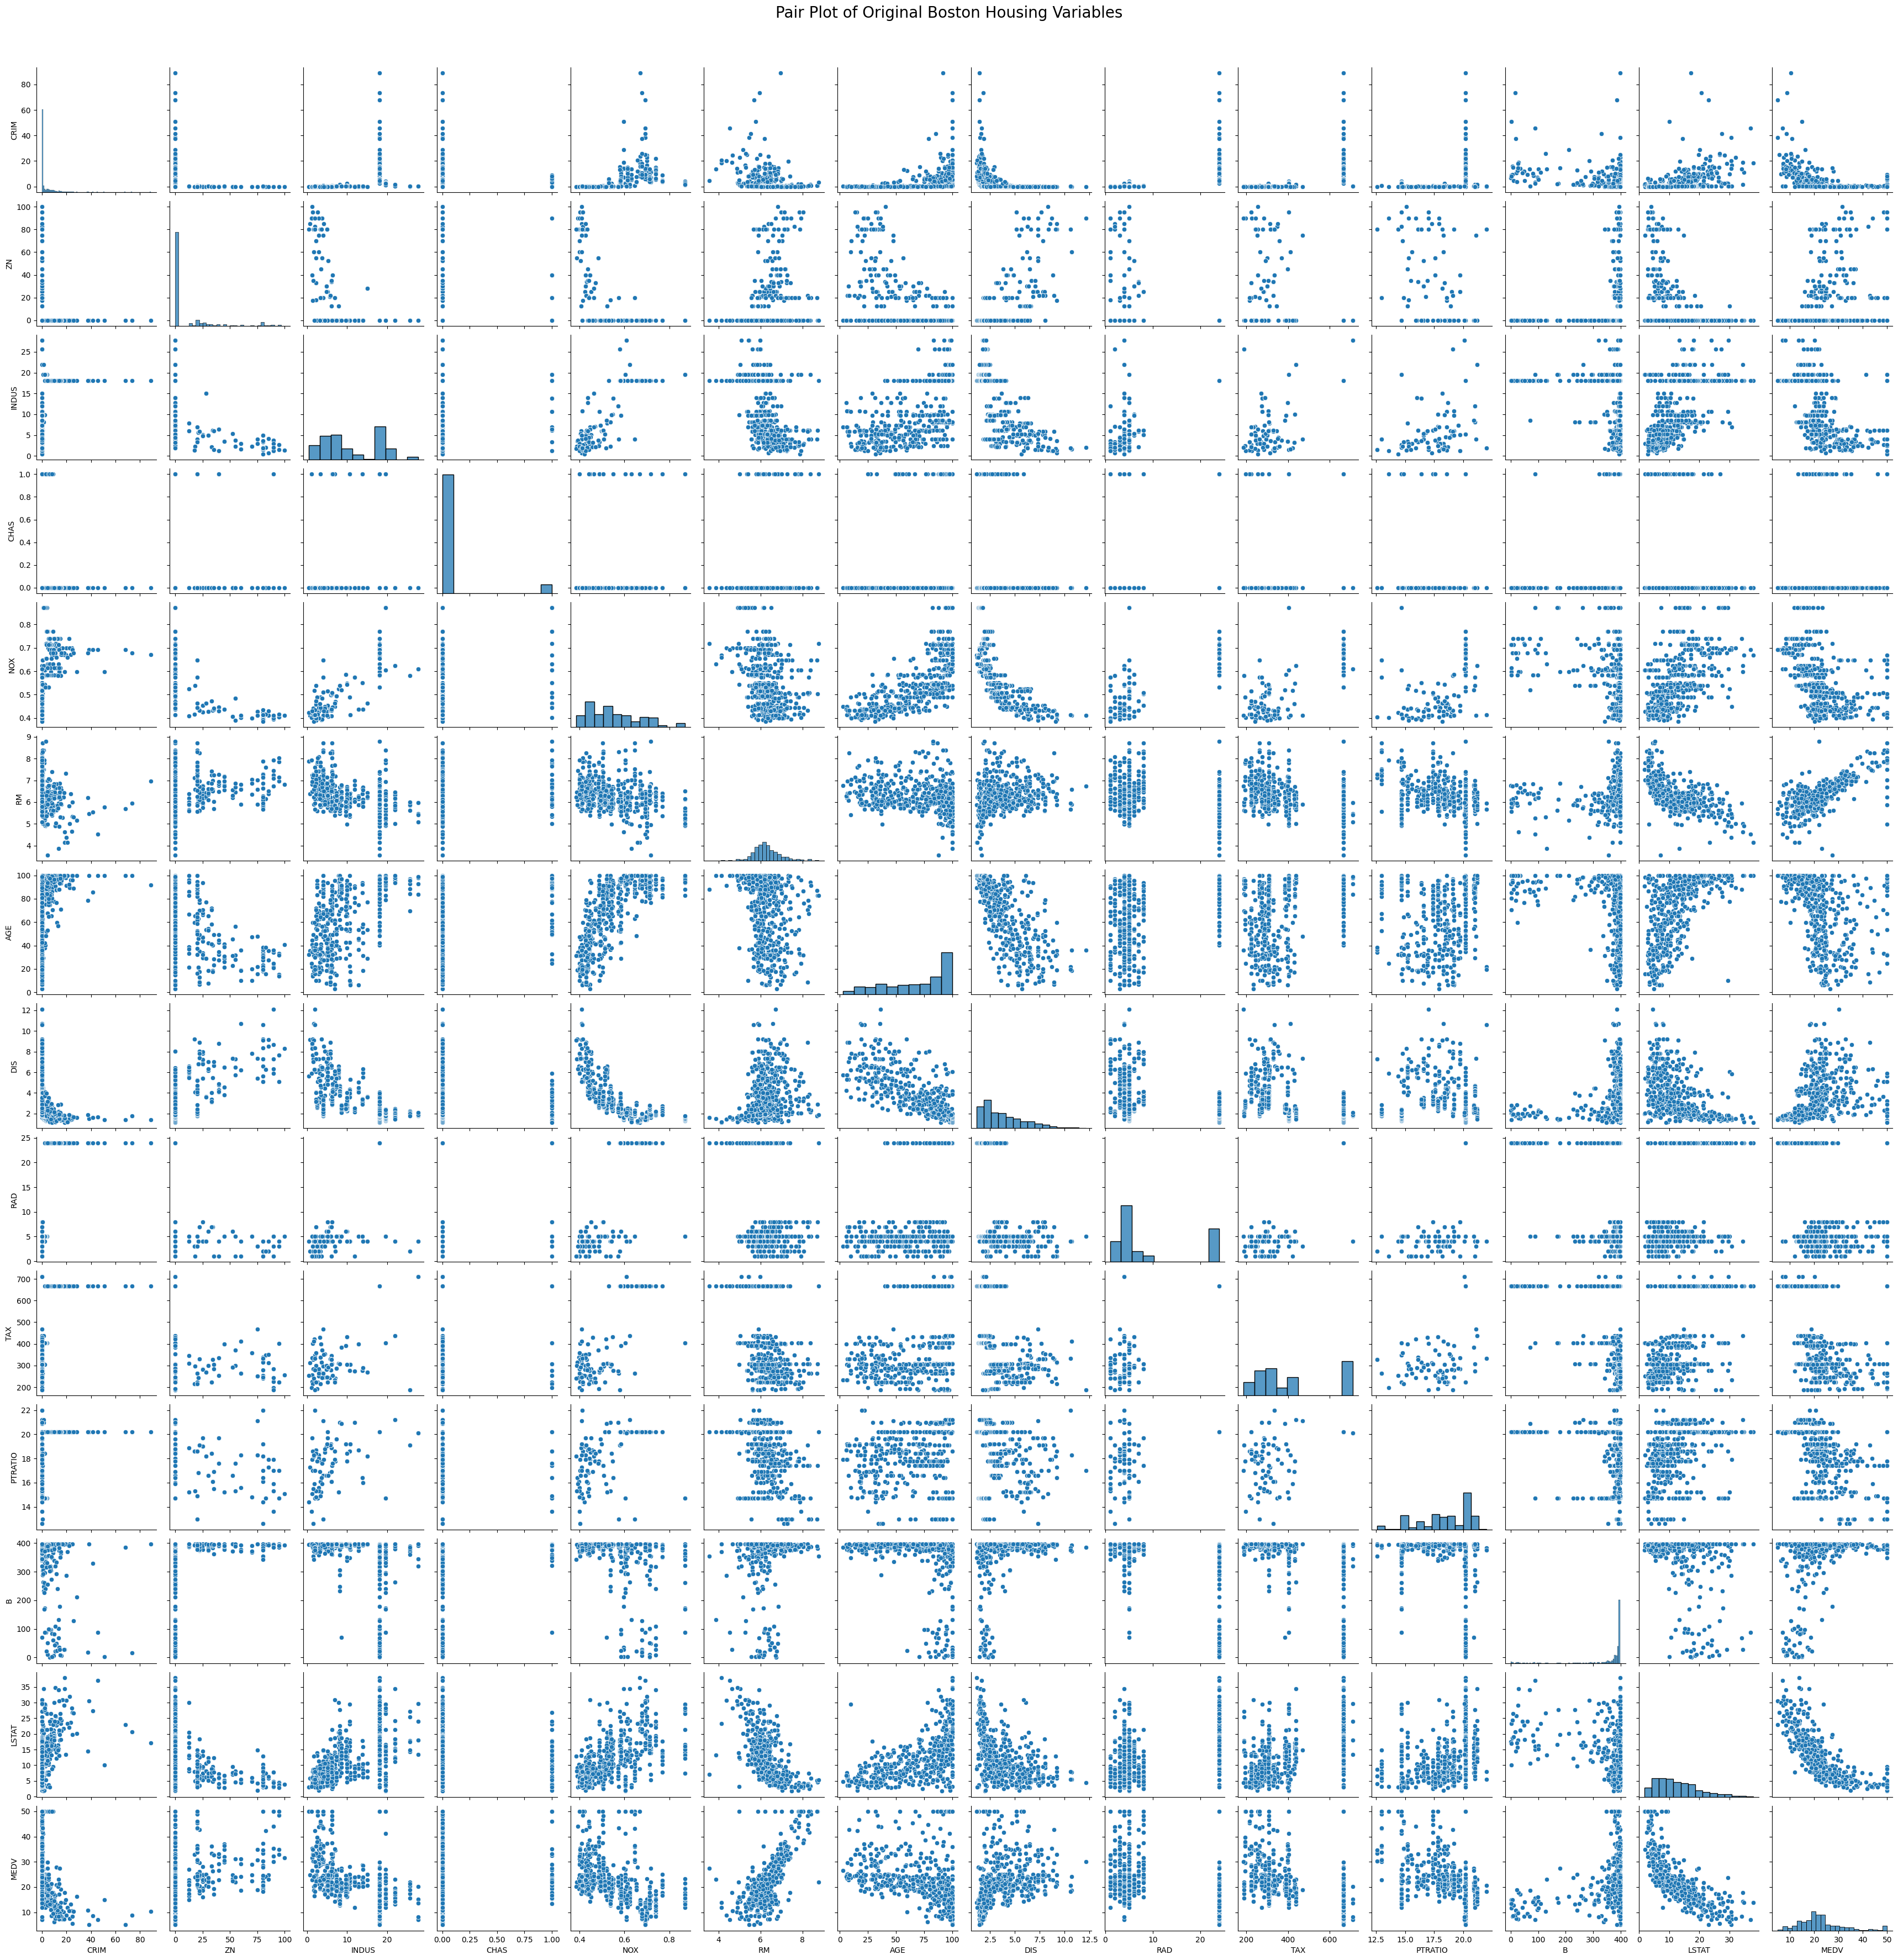

In [ ]:
# Pair plot 1
# original Boston Housing variables
original_features = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

# pair plot
sns.pairplot(data[original_features], diag_kind='hist')
plt.suptitle('Pair Plot of Original Boston Housing Variables', y=1.02, fontsize=20)
plt.savefig(graphics_path + 'original_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

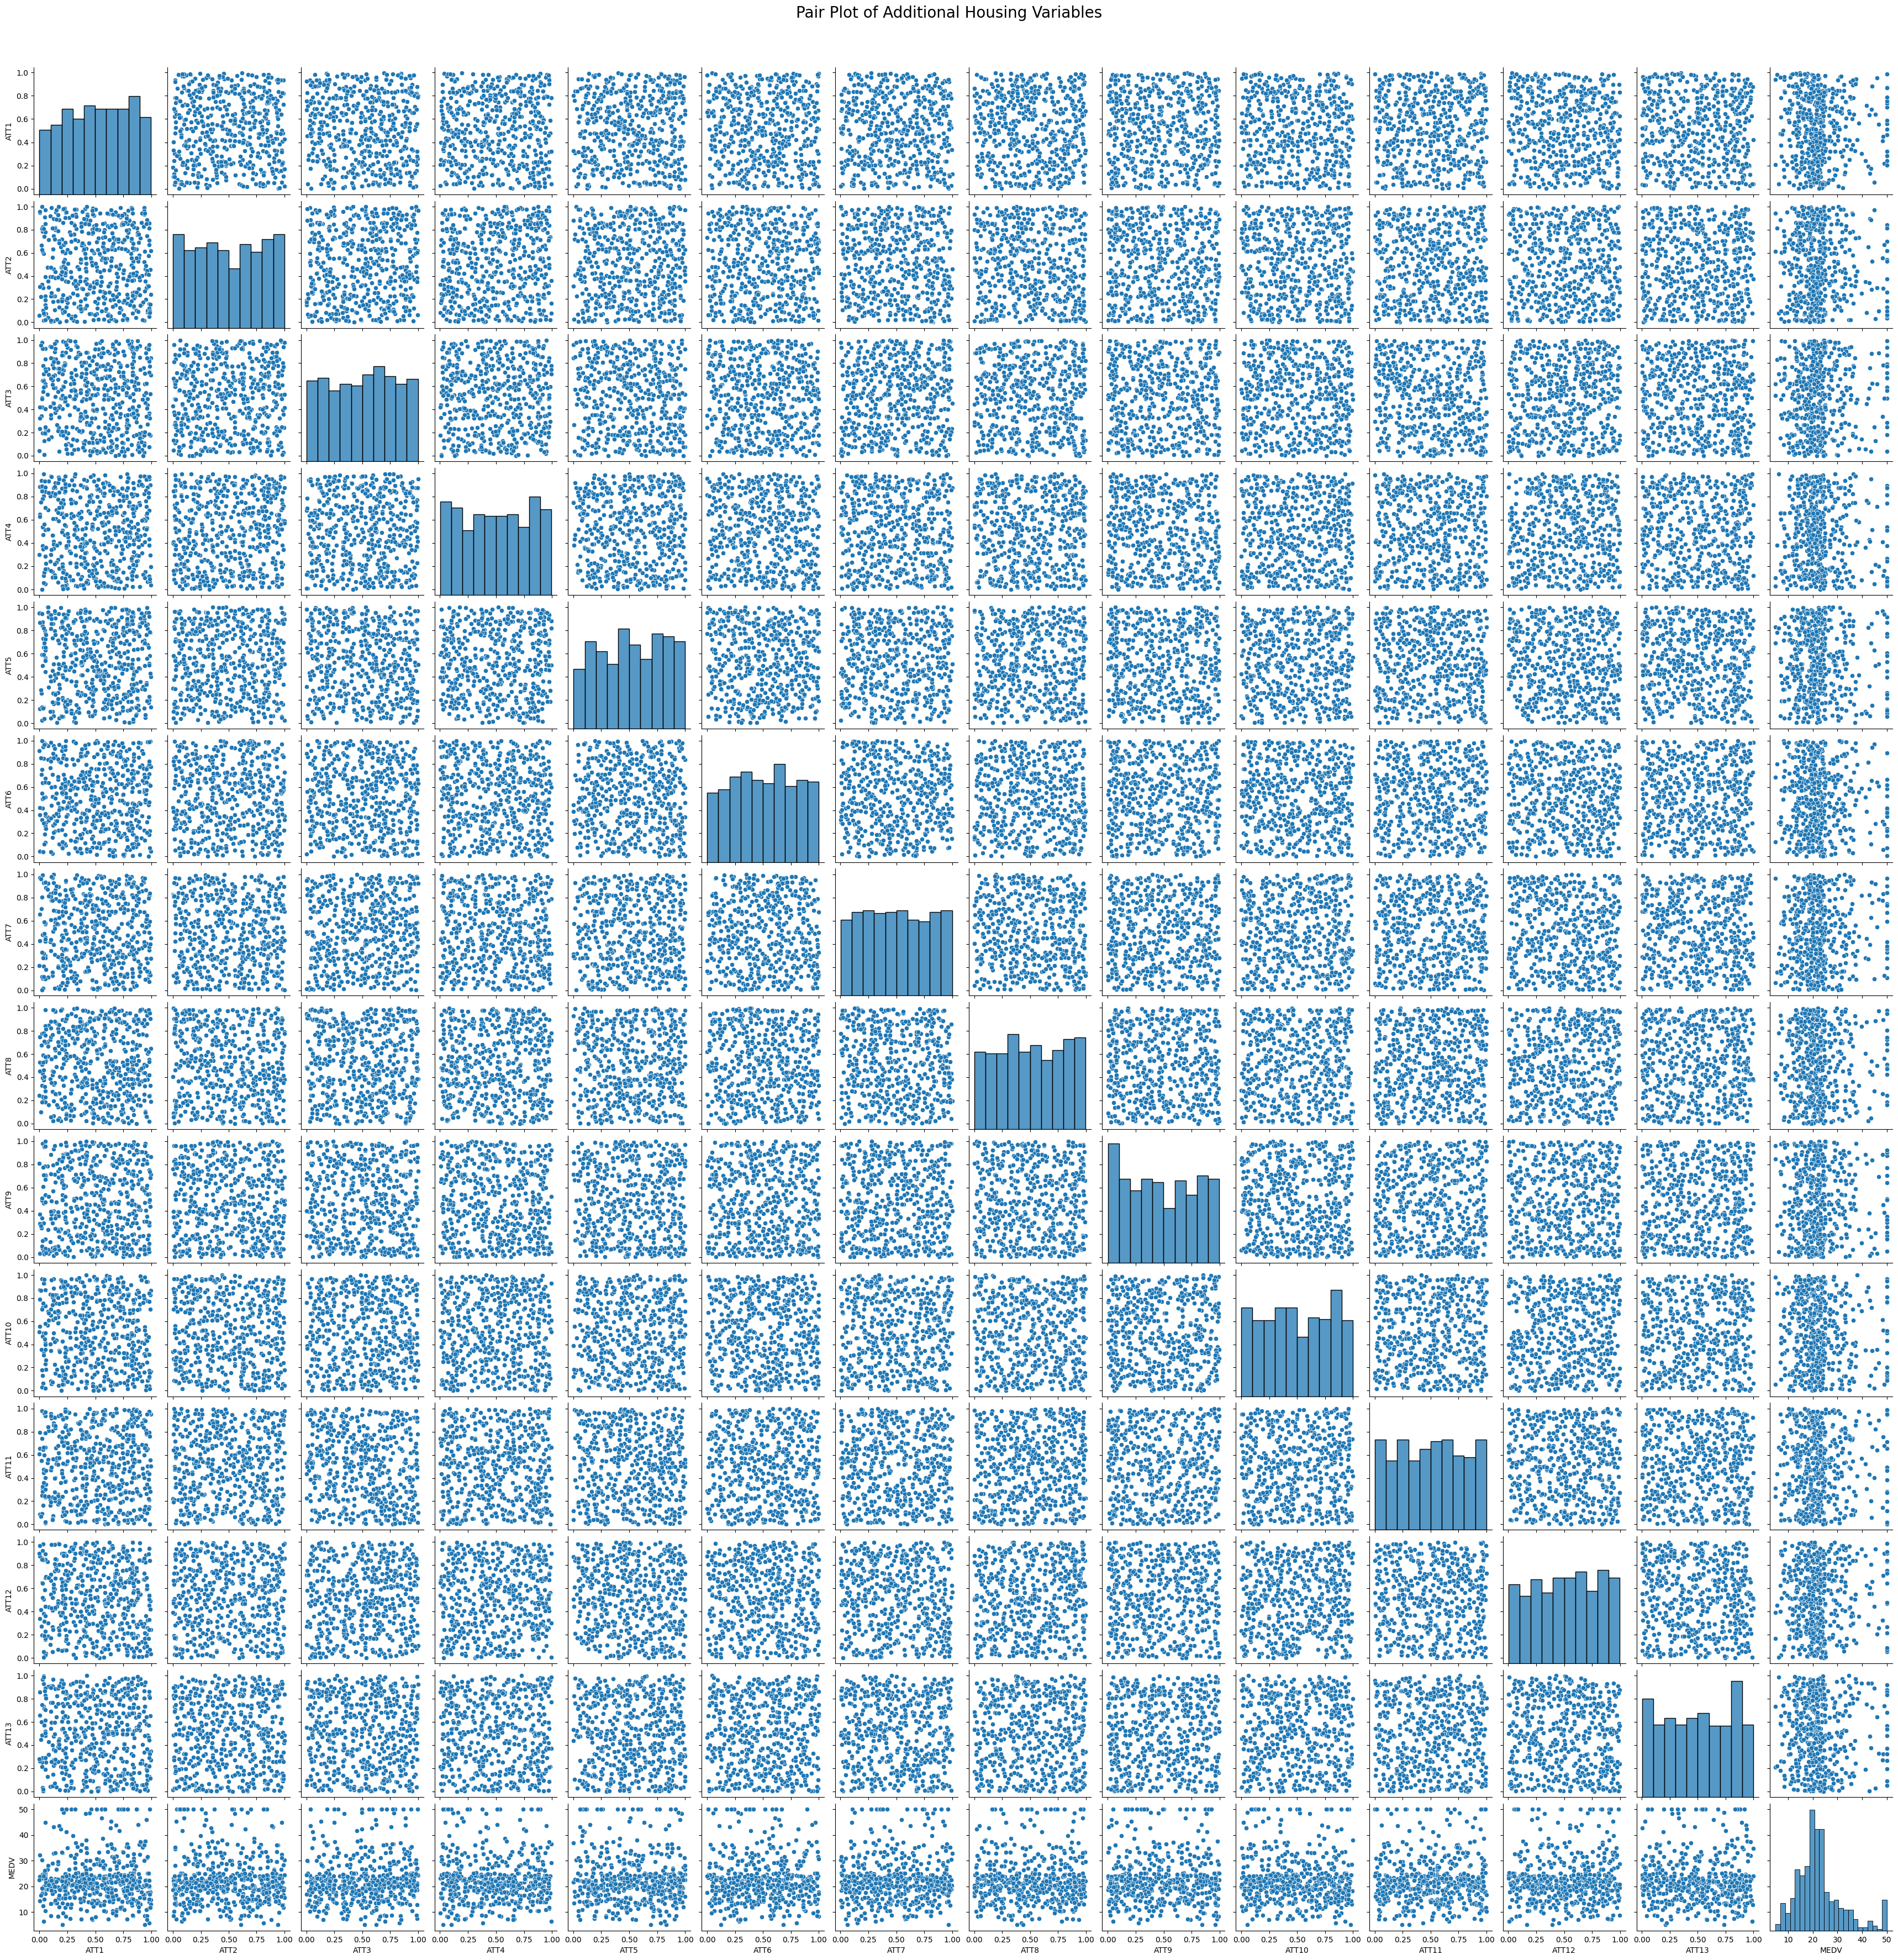

In [ ]:
# Pair plot 2
# additional variables
additional_features = ['ATT1', 'ATT2', 'ATT3', 'ATT4', 'ATT5', 'ATT6',
    'ATT7', 'ATT8', 'ATT9', 'ATT10', 'ATT11', 'ATT12', 'ATT13', 'MEDV']

# pair plot: additional variables
sns.pairplot(data[additional_features], diag_kind='hist')
plt.suptitle('Pair Plot of Additional Housing Variables', y=1.02, fontsize=20)
plt.savefig(graphics_path + 'additional_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Regression Models

We first standardize the features.

In [6]:
from sklearn.preprocessing import StandardScaler

# Standardize features using only the training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# convert back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

## 3.1 Linear Regression

We first fit a linear regression model. This provides a baseline model that we can later compare with Ridge and LASSO regression.

In [7]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Fit the linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [8]:
# Model coefficients and intercept
print("Intercept:", lr_model.intercept_)

coefficients = pd.DataFrame({'Feature': X_train.columns,'Coefficient': lr_model.coef_})
print("\nCoefficients:")
display(coefficients)

Intercept: 22.796534653465343

Coefficients:


,Feature,Coefficient
0,ATT1,0.815768
1,ATT2,-0.071675
2,ATT3,0.162673
3,ATT4,-0.030953
4,ATT5,-0.216897
5,ATT6,-0.174362
6,ATT7,0.189452
7,ATT8,-0.079865
8,ATT9,-0.042841
9,ATT10,-0.292699


Test MSE: 26.6302
Test R²: 0.6369


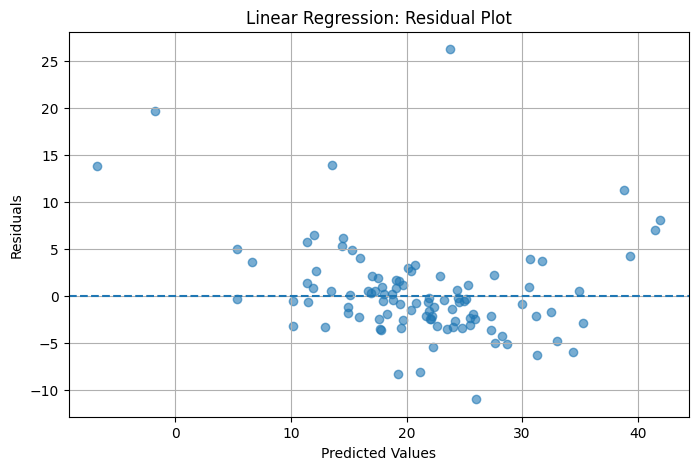

In [10]:
# Predictions
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

# Performance metrics
mse = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print(f"Test MSE: {mse:.4f}")
print(f"Test R²: {r2:.4f}")

# Calculate residuals
residuals = y_test - y_test_pred

# Plot residual errors
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Linear Regression: Residual Plot')
plt.grid(True)
plt.savefig(graphics_path + 'Linear_Regression_Residual_Plot.png', dpi=300, bbox_inches='tight')
plt.show()

## 3.2 Ridge Regression

We next use Ridge regression to reduce the impact of potentially large or unstable coefficients (those additionaly random attributes). The regularization strength is controlled by the parameter $\alpha$.

In [22]:
### Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define Ridge model
ridge_model = Ridge()

We test a range of $\alpha$ values in $[10^{-3}, 10^2]$ using 5-fold cross-validation. Cross-validation helps us select the $\alpha$ that provides the lowest validation MSE.

In [23]:
# test different alpha values with cross-validation
alpha_values = np.logspace(-3, 2, 30)
param_grid = {'alpha': alpha_values}

# cross-validation
ridge_cv = GridSearchCV(estimator=ridge_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

# best alpha
best_alpha = ridge_cv.best_params_['alpha']
print("Best alpha:", best_alpha)

Best alpha: 9.236708571873866


,param_alpha,CV_MSE,std_test_score
0,0.001000,25.240064,4.594364
1,0.001487,25.240054,4.594368
2,0.002212,25.240039,4.594373
3,0.003290,25.240017,4.594381
4,0.004894,25.239985,4.594394
5,0.007279,25.239936,4.594412
6,0.010826,25.239864,4.594439
7,0.016103,25.239757,4.594480
8,0.023950,25.239598,4.594540
9,0.035622,25.239362,4.594630


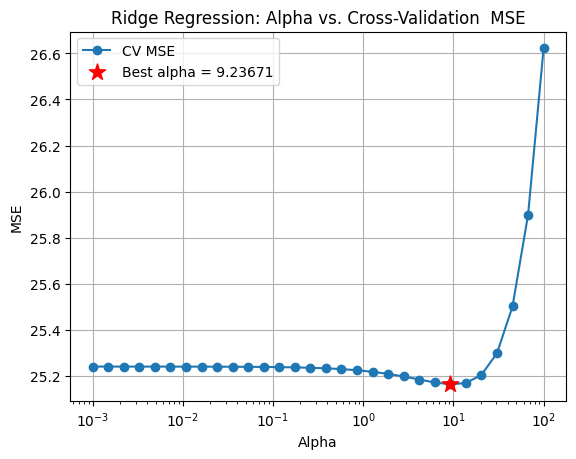

In [24]:
# Display cross-validation results
cv_results = pd.DataFrame(ridge_cv.cv_results_)
alpha_comparison = cv_results[['param_alpha', 'mean_test_score', 'std_test_score']].copy()
alpha_comparison['CV_MSE'] = -alpha_comparison['mean_test_score'] # convert negative MSE into positive MSE
alpha_comparison = alpha_comparison[['param_alpha', 'CV_MSE', 'std_test_score']]
display(alpha_comparison)

# CV MSE
plt.plot(alpha_comparison['param_alpha'], alpha_comparison['CV_MSE'], marker='o', label='CV MSE')
# best alpha
best_cv_mse = alpha_comparison.loc[alpha_comparison['param_alpha'] == best_alpha, 'CV_MSE'].iloc[0]
plt.scatter(best_alpha, best_cv_mse, s=150, marker='*', color='red', zorder=5, label=f'Best alpha = {round(best_alpha,5)}') # best alpha
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.legend()
plt.title('Ridge Regression: Alpha vs. Cross-Validation  MSE')
plt.grid(True)
plt.savefig(graphics_path + 'Ridge_Regression_Cross_Validation_MSE.png', dpi=300, bbox_inches='tight')
plt.show()

The CV MSE plot shows how model performance changes with $\alpha$. We select $\alpha = 9.2367$ with the lowest cross-validation MSE as the best $\alpha$.

We then examine the coefficient paths to understand how Ridge regularization affects the model as $\alpha$ increases. We expect stronger regularization to shrink the coefficients of the randomly generated attributes toward zero more quickly.

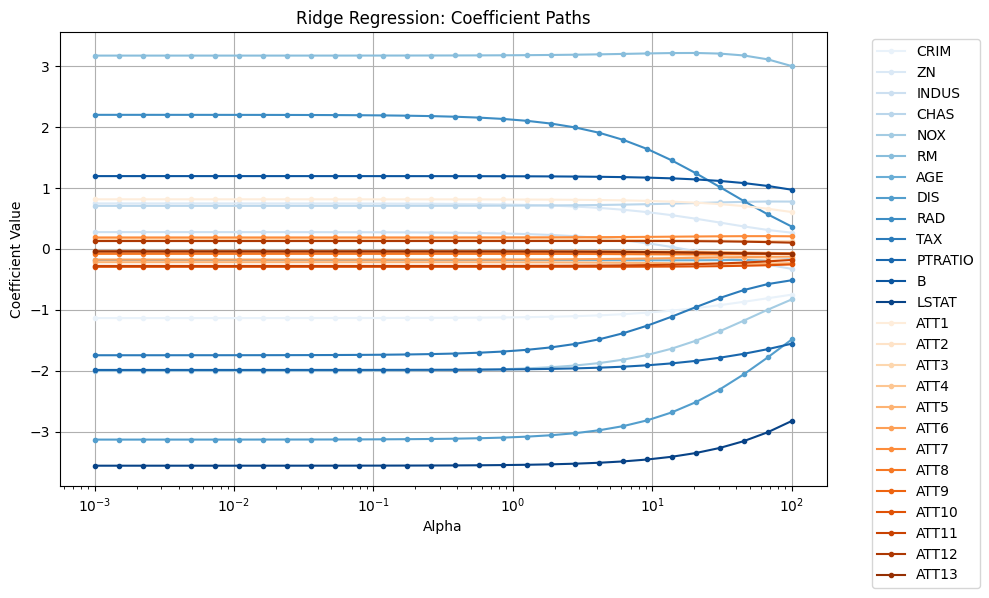

In [14]:
# Store coefficients for each alpha
coefficients = []
for alpha in alpha_values:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    coefficients.append(model.coef_)
coefficients = pd.DataFrame(coefficients, columns=X_train_scaled.columns, index=alpha_values)

# Set different palette for original and additional features
original_features = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
additional_features = [f'ATT{i}' for i in range(1, 14)]
original_colors = sns.color_palette("Blues", len(original_features))
additional_colors = sns.color_palette("Oranges", len(additional_features))

# Plot coefficient paths
plt.figure(figsize=(10, 6))

for feature, color in zip(original_features, original_colors):
    plt.plot(coefficients.index, coefficients[feature], color=color,
             marker='o', markersize=3, label=feature)

for feature, color in zip(additional_features, additional_colors):
    plt.plot(coefficients.index, coefficients[feature], color=color,
             marker='o', markersize=3, label=feature)

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression: Coefficient Paths')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(graphics_path + 'Ridge_Regression_Coefficient_Paths.png', dpi=300, bbox_inches='tight')
plt.show()

After selecting the best $\alpha$ through cross-validation, we use the corresponding Ridge model to make predictions on the test set.


Intercept: 22.796534653465343

Coefficients:


,Feature,Coefficient
0,ATT1,0.790025
1,ATT2,-0.092556
2,ATT3,0.149631
3,ATT4,-0.037466
4,ATT5,-0.230034
5,ATT6,-0.156425
6,ATT7,0.199075
7,ATT8,-0.084726
8,ATT9,-0.050741
9,ATT10,-0.290299


Test MSE: 26.7404
Test R²: 0.6354


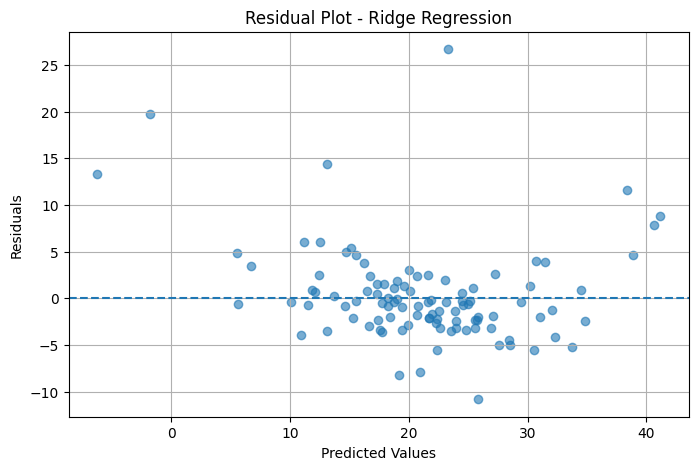

In [15]:
# Fit the best Ridge model
best_ridge = ridge_cv.best_estimator_

# Model intercept & coefficients
print("\nIntercept:", best_ridge.intercept_)

ridge_coefficients = pd.DataFrame({'Feature': X_train_scaled.columns, 'Coefficient': best_ridge.coef_})
print("\nCoefficients:")
display(ridge_coefficients)

# Predictions
y_test_pred_ridge = best_ridge.predict(X_test_scaled)

# Performance metrics
ridge_mse = mean_squared_error(y_test, y_test_pred_ridge)
ridge_r2 = r2_score(y_test, y_test_pred_ridge)

print(f"Test MSE: {ridge_mse:.4f}")
print(f"Test R²: {ridge_r2:.4f}")

# Calculate residuals
ridge_residuals = y_test - y_test_pred_ridge

# Plot residual errors
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred_ridge, ridge_residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Ridge Regression')
plt.grid(True)
plt.savefig(graphics_path + 'Ridge_Regression_Residual_Plot.png', dpi=300, bbox_inches='tight')
plt.show()

## 3.3 Lasso Regression


We next fit a LASSO regression model. LASSO adds an L1 penalty that can shrink some coefficients exactly to zero, which can also perform feature selection.

In [16]:
from sklearn.linear_model import Lasso

# Define LASSO model
lasso_model = Lasso(max_iter=10000)

We test a range of $\alpha$ values using 5-fold cross-validation. This allows us to select the regularization strength that gives the lowest validation MSE.

In [17]:
# Test different alpha values with cross-validation
alpha_values_lasso = np.logspace(-3, 2, 30)
param_grid_lasso = {'alpha': alpha_values_lasso}

# Cross-validation
lasso_cv = GridSearchCV(estimator=lasso_model, param_grid=param_grid_lasso, cv=5, scoring='neg_mean_squared_error')
lasso_cv.fit(X_train_scaled, y_train)

# Best alpha
best_alpha_lasso = lasso_cv.best_params_['alpha']
print("Best alpha:", best_alpha_lasso)

Best alpha: 0.1743328822199989


,param_alpha,CV_MSE,std_test_score
0,0.001000,25.230612,4.596543
1,0.001487,25.226077,4.597617
2,0.002212,25.219417,4.599227
3,0.003290,25.209374,4.601686
4,0.004894,25.195254,4.605091
5,0.007279,25.175649,4.609767
6,0.010826,25.148647,4.616708
7,0.016103,25.110218,4.628004
8,0.023950,25.063572,4.644669
9,0.035622,25.010155,4.666686


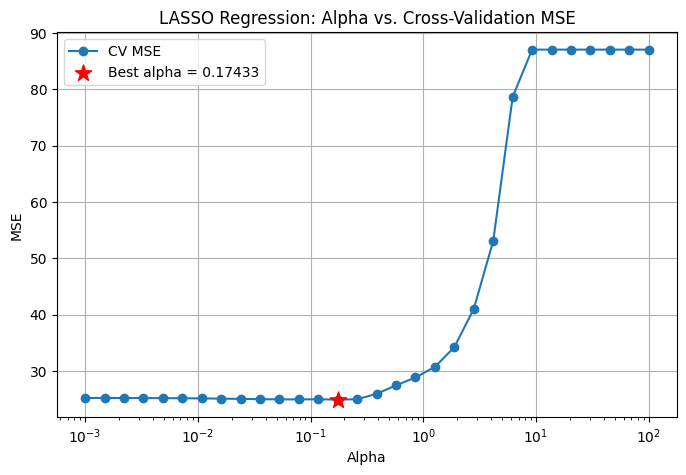

In [18]:
# Display cross-validation results
cv_results_lasso = pd.DataFrame(lasso_cv.cv_results_)

alpha_comparison_lasso = cv_results_lasso[['param_alpha', 'mean_test_score', 'std_test_score']].copy()
alpha_comparison_lasso['CV_MSE'] = -alpha_comparison_lasso['mean_test_score']
alpha_comparison_lasso = alpha_comparison_lasso[['param_alpha', 'CV_MSE', 'std_test_score']]

display(alpha_comparison_lasso)

# Plot CV MSE
plt.figure(figsize=(8, 5))

plt.plot(alpha_comparison_lasso['param_alpha'], alpha_comparison_lasso['CV_MSE'], marker='o', label='CV MSE')

# Best alpha
best_cv_mse_lasso = alpha_comparison_lasso.loc[alpha_comparison_lasso['param_alpha'] == best_alpha_lasso, 'CV_MSE'].iloc[0]
plt.scatter(best_alpha_lasso, best_cv_mse_lasso, s=150,marker='*', color='red', zorder=5,
            label=f'Best alpha = {round(best_alpha_lasso, 5)}')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.legend()
plt.title('LASSO Regression: Alpha vs. Cross-Validation MSE')
plt.grid(True)
plt.savefig(graphics_path + 'LASSO_Regression_Cross_Validation_MSE.png', dpi=300, bbox_inches='tight')
plt.show()

The CV MSE plot shows how model performance changes with $\alpha$. We select $\alpha = 0.17433$ with the lowest cross-validation MSE as the best regularization strength.

We then examine the coefficient paths to understand how LASSO regularization affects the model as $\alpha$ increases. Unlike Ridge, LASSO can shrink coefficients exactly to zero, potentially removing less important attributes from the model.

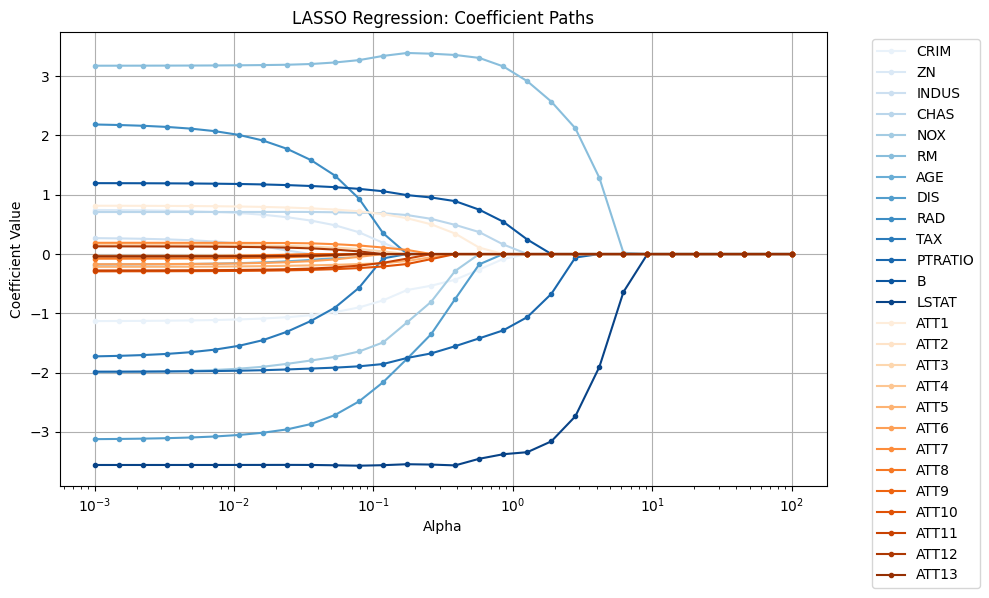

In [19]:
# Store coefficients for each alpha
coefficients_lasso = []

for alpha in alpha_values_lasso:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    coefficients_lasso.append(model.coef_)

coefficients_lasso = pd.DataFrame(coefficients_lasso, columns=X_train_scaled.columns, index=alpha_values_lasso)

# Use two palettes for original and additional features
original_colors = sns.color_palette("Blues", len(original_features))
additional_colors = sns.color_palette("Oranges", len(additional_features))

# Plot coefficient paths
plt.figure(figsize=(10, 6))

for feature, color in zip(original_features, original_colors):
    plt.plot(coefficients_lasso.index,coefficients_lasso[feature],
        color=color, marker='o', markersize=3, label=feature)

for feature, color in zip(additional_features, additional_colors):
    plt.plot(coefficients_lasso.index, coefficients_lasso[feature], color=color, marker='o',
        markersize=3, label=feature)

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('LASSO Regression: Coefficient Paths')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(graphics_path + 'LASSO_Regression_Coefficient_Paths.png', dpi=300, bbox_inches='tight')
plt.show()

After selecting the best $\alpha$ through cross-validation, we use the corresponding LASSO model to make predictions on the test set. We examine the intercept and coefficients to see which features remain in the model.

In [20]:
# Fit the best LASSO model
best_lasso = lasso_cv.best_estimator_

# Model intercept and coefficients
print("Intercept:", best_lasso.intercept_)

lasso_coefficients = pd.DataFrame({'Feature': X_train_scaled.columns, 'Coefficient': best_lasso.coef_})

print("\nCoefficients:")
display(lasso_coefficients)

# Identify features with coefficients exactly equal to zero
zero_coefficients = lasso_coefficients[lasso_coefficients['Coefficient'] == 0]

print(f"\nNumber of coefficients shrunk to zero: {len(zero_coefficients)}")
print("Features removed by LASSO:")
display(zero_coefficients)

Intercept: 22.796534653465343

Coefficients:


,Feature,Coefficient
0,ATT1,0.603134
1,ATT2,-0.000000
2,ATT3,0.000000
3,ATT4,-0.000000
4,ATT5,-0.117304
5,ATT6,-0.000000
6,ATT7,0.068919
7,ATT8,-0.000000
8,ATT9,-0.000000
9,ATT10,-0.168597



Number of coefficients shrunk to zero: 12
Features removed by LASSO:


,Feature,Coefficient
1,ATT2,-0.0
2,ATT3,0.0
3,ATT4,-0.0
5,ATT6,-0.0
7,ATT8,-0.0
8,ATT9,-0.0
11,ATT12,0.0
12,ATT13,-0.0
15,INDUS,-0.0
19,AGE,-0.0


We evaluate the final LASSO model using test MSE and R² and examine the residual plot. These results can be compared with the linear regression and Ridge models.

Test MSE: 28.9058
Test R²: 0.6058


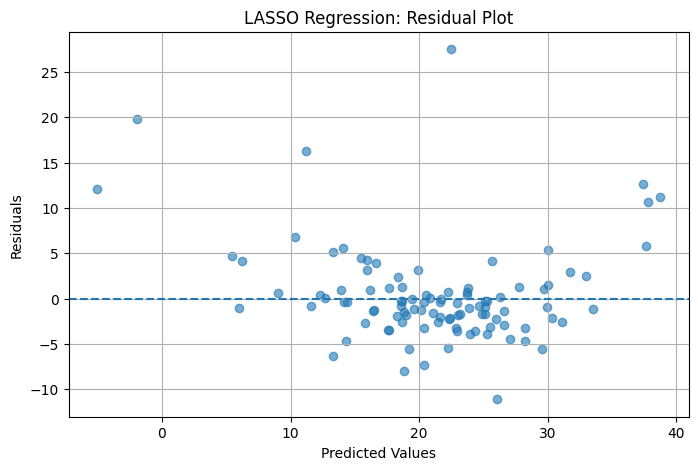

In [21]:
# Predictions
y_test_pred_lasso = best_lasso.predict(X_test_scaled)

# Performance metrics
lasso_mse = mean_squared_error(y_test, y_test_pred_lasso)
lasso_r2 = r2_score(y_test, y_test_pred_lasso)

print(f"Test MSE: {lasso_mse:.4f}")
print(f"Test R²: {lasso_r2:.4f}")

# Calculate residuals
lasso_residuals = y_test - y_test_pred_lasso

# Plot residual errors
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred_lasso, lasso_residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('LASSO Regression: Residual Plot')
plt.grid(True)
plt.savefig(graphics_path + 'LASSO_Regression_Residual_Plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [1]:
print("My name is Rong Gan")
print("My NetID is: ronggan2")
print("I hereby certify that I have read the University policy on Academic Integrity and that I am not in violation.")

My name is Rong Gan
My NetID is: ronggan2
I hereby certify that I have read the University policy on Academic Integrity and that I am not in violation.
